<img src="../../../assets/images/logos/ucu_logo_clean.svg" alt="UCU Logo" width="200" style="float: right; margin: 0 0 10px 10px;"/>

### Matemáticas para Aprendizaje Automático - 2026

--------
## Laboratorio 1.1: Introducción al Álgebra Lineal con NumPy

#### Objetivos

- Crear y caracterizar vectores y matrices en NumPy, comprendiendo su forma, dimensión y tipo de dato.
- Aplicar indexación, rebanado e indexación booleana para acceder y modificar sus elementos.
- Implementar operaciones fundamentales del álgebra lineal (producto punto, normas, producto matricial, determinante e inversa) y conectarlas con su definición matemática.
- Utilizar *broadcasting* para escribir código vectorizado, eficiente y sin bucles explícitos.

## Introducción

El álgebra lineal es el lenguaje en el que se expresan la mayoría de los algoritmos de aprendizaje automático: los datos se representan como vectores y matrices, y entrenar un modelo consiste, en buena medida, en realizar operaciones sobre esos objetos. Dominar estas operaciones y saber implementarlas de forma eficiente, es un requisito previo para todo lo que sigue en el curso.

En este laboratorio usarás **NumPy**, la librería estándar de Python para cómputo numérico, para construir paso a paso las herramientas fundamentales del álgebra lineal. Trabajarás con vectores y funciones del tipo $f:\mathbb{R}^n \to \mathbb{R}$, con matrices en $\mathbb{R}^{m \times n}$, y con
el mecanismo de *broadcasting* que permite escribir código vectorizado y veloz. El práctico se
organiza en tres partes: 

1. **Vectores**
2. **Matrices**
3. **Broadcasting**

Cada parte abre con una breve introducción teórica que alcanza para resolver sus ejercicios, y cada ejercicio termina con un **bloque de verificación** para que compruebes tu resultado.

**Requisitos previos.** Python 3.x con NumPy y Matplotlib instalados.

In [1]:
# Librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import timeit

## Parte 1: Vectores en NumPy

Un **vector** de dimensión $n$ es un elemento $\mathbf{v} \in \mathbb{R}^n$, es decir, una tupla ordenada de $n$ números reales $\mathbf{v} = (v_1, v_2, \dots, v_n)$. En NumPy los vectores se representan como **arreglos unidimensionales** (`ndarray` de una dimensión): todos sus elementos comparten un mismo tipo de dato y el tamaño es fijo.

Sobre vectores definimos las operaciones básicas del álgebra lineal. Dados $\mathbf{a}, \mathbf{b}
\in \mathbb{R}^n$ y un escalar $\alpha \in \mathbb{R}$:

$$\mathbf{a} + \mathbf{b} = (a_1 + b_1, \dots, a_n + b_n), \qquad
  \alpha\,\mathbf{a} = (\alpha\,a_1, \dots, \alpha\,a_n).$$

El **producto punto** (o producto interno) resume la relación entre dos vectores en un escalar:

$$\langle \mathbf{a}, \mathbf{b} \rangle = \mathbf{a} \cdot \mathbf{b} = \sum_{i=1}^{n} a_i\,b_i.$$

La **norma** mide la "longitud" de un vector. Usaremos las tres más frecuentes:

$$\|\mathbf{a}\|_1 = \sum_{i=1}^{n} |a_i|, \qquad
  \|\mathbf{a}\|_2 = \sqrt{\sum_{i=1}^{n} a_i^2}, \qquad
  \|\mathbf{a}\|_\infty = \max_i |a_i|.$$

En esta parte crearás vectores de distintas formas, accederás a sus elementos mediante indexación y rebanado, y aplicarás estas operaciones. Cada ejercicio termina con un bloque de verificación que compara tu resultado con el valor esperado.

### Creación y propiedades de vectores

Existen múltiples formas de instanciar vectores según lo que se busque. Es posible consultar la
dimensión del arreglo (`.ndim`), el tamaño de cada dimensión (`.shape`) y el tipo de dato de los
elementos (`.dtype`) mediante los atributos correspondientes, como se ve en la siguiente celda
(ejecutala para ver el resultado).

In [2]:
# Creando un vector a partir de una lista
vec1 = np.array([1, 2, 3, 4, 5])
print(f"Vector a partir de lista: {vec1}")
print(f"Tipo: {type(vec1)}")
print(f"Forma: {vec1.shape}")
print(f"Dimensión: {vec1.ndim}")

# Creando un vector de ceros
vec2 = np.zeros(5)
print(f"\nVector de ceros: {vec2}")
print(f"Forma: {vec2.shape}")

# Creando un vector de unos
vec3 = np.ones(4)
print(f"\nVector de unos: {vec3}")

# Creando un vector aleatorio
vec4 = np.random.random(3)
print(f"\nVector aleatorio: {vec4}")

Vector a partir de lista: [1 2 3 4 5]
Tipo: <class 'numpy.ndarray'>
Forma: (5,)
Dimensión: 1

Vector de ceros: [0. 0. 0. 0. 0.]
Forma: (5,)

Vector de unos: [1. 1. 1. 1.]

Vector aleatorio: [0.3020219  0.08759594 0.5913797 ]


### Ejercicio L1.1.1: Creación de un vector a partir de una lista

Creá un vector NumPy que contenga los valores $1$, $2$ y $3$.

In [4]:
# ── Ejercicio L1.1.1 ──
vec_1_1_1 = np.array([1, 2, 3])  # COMPLETAR: crear el vector [1, 2, 3]
print("Vector obtenido:", vec_1_1_1)

# ── Verificación ─────────────────────────────────────────────────────────────
assert isinstance(vec_1_1_1, np.ndarray), "El resultado debe ser un np.ndarray"
print("✓ Verificación L1.1.1 superada")

Vector obtenido: [1 2 3]
✓ Verificación L1.1.1 superada


### Ejercicio L1.1.2: Vector constante de longitud 1000

Creá un vector NumPy de longitud $1000$ que consista únicamente del valor $2.2$.

In [6]:
# ── Ejercicio L1.1.2 ──
vec_1_1_2 = np.array([2.2] * 1000)  # COMPLETAR: vector de 1000 elementos, todos iguales a 2.2
print("Forma:", np.shape(vec_1_1_2), "| primer valor:", vec_1_1_2[0])

# ── Verificación ─────────────────────────────────────────────────────────────
assert vec_1_1_2.shape == (1000,), "El vector debe tener longitud 1000"
assert np.allclose(vec_1_1_2, 2.2), "Todos los elementos deben valer 2.2"
print("✓ Verificación L1.1.2 superada")

Forma: (1000,) | primer valor: 2.2
✓ Verificación L1.1.2 superada


### Ejercicio L1.1.3: Valores equiespaciados

Creá un vector de valores equiespaciados (con la función de NumPy indicada) desde $0$ hasta $10$ (**inclusive**) con $5$ elementos.
Buscar en la documentación de NumPy para encontrar que función genera un vector equispaciado.


In [8]:
# ── Ejercicio L1.1.3 ──
vec_1_1_3 = np.linspace(0, 10, 5)  # COMPLETAR: 5 valores equiespaciados en [0, 10]
print("Vector obtenido:", vec_1_1_3)

# ── Verificación ─────────────────────────────────────────────────────────────
assert vec_1_1_3.shape == (5,), "El vector debe tener 5 elementos"
assert np.allclose(vec_1_1_3, [0, 2.5, 5, 7.5, 10]), "Los valores no coinciden con lo esperado"
print("✓ Verificación L1.1.3 superada")

Vector obtenido: [ 0.   2.5  5.   7.5 10. ]
✓ Verificación L1.1.3 superada


### Ejercicio L1.1.4: Muestreo y gráfica del seno

**a)** Creá un vector de $20$ valores equiespaciados entre $0$ y $2\pi$.

**b)** Calculá el seno de cada valor.

**c)** Graficá el resultado ($\sin(x)$ en función de $x$).

**Nota:** usá `np.pi`, `np.sin` y `plt.plot`.

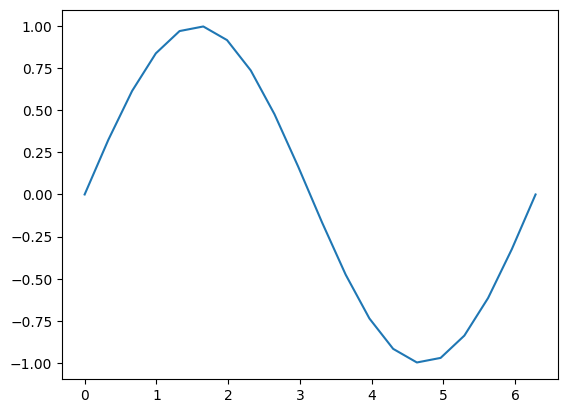

TypeError: unsupported operand type(s) for -: 'ellipsis' and 'float'

In [ ]:
# ── Ejercicio L1.1.4 ──
x_1_1_4 = np.linspace(0, 2 * np.pi, 20)  # COMPLETAR (a): 20 valores equiespaciados en [0, 2*pi]
sen_1_1_4 = np.sin(x_1_1_4)  # COMPLETAR (b): seno de cada valor

# COMPLETAR (c): graficar sen_1_1_4 en función de x_1_1_4
plt.plot(x_1_1_4, sen_1_1_4)
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Sine function")
plt.grid(True)
plt.show()

# ── Verificación ─────────────────────────────────────────────────────────────
assert x_1_1_4.shape == (20,), "x debe tener 20 elementos"
assert np.isclose(x_1_1_4[0], 0) and np.isclose(x_1_1_4[-1], 2 * np.pi), "El rango debe ser [0, 2*pi]"
assert np.allclose(sen_1_1_4, np.sin(x_1_1_4)), "sen_1_1_4 debe ser el seno de x_1_1_4"
print("✓ Verificación L1.1.4 superada")

### Ejercicio L1.1.5: Distribuciones de `numpy.random`

¿A qué distribución aleatoria corresponden los elementos de un vector creado con
`numpy.random.random`? ¿Y con `numpy.random.randn`?

Verificalo creando un vector de largo $1000$ con cada función y graficando un histograma de los
valores generados (podés usar `plt.hist`). Respondé la pregunta en el comentario final de la celda.

In [ ]:
# ── Ejercicio L1.1.5 ──
r_1_1_5 = ...  # COMPLETAR: 1000 valores con np.random.random
g_1_1_5 = ...  # COMPLETAR: 1000 valores con np.random.randn

# COMPLETAR: graficar un histograma de cada vector (por ejemplo, con plt.subplot)
...  # COMPLETAR

# Respondé aquí: ¿a qué distribución corresponde cada función?
# np.random.random -> ...
# np.random.randn  -> ...

# ── Verificación ─────────────────────────────────────────────────────────────
assert r_1_1_5.shape == (1000,) and g_1_1_5.shape == (1000,), "Cada vector debe tener largo 1000"
assert np.all((r_1_1_5 >= 0) & (r_1_1_5 < 1)), "random() genera valores en el intervalo [0, 1)"
assert abs(g_1_1_5.mean()) < 0.2 and 0.8 < g_1_1_5.std() < 1.2, "randn() ~ Normal(0, 1)"
print("✓ Verificación L1.1.5 superada")

### Acceso a elementos de vectores

NumPy proporciona capacidades de indexación para acceder a elementos específicos de los vectores y para obtener sub-vectores. La indexación, al igual que en Python, es de **base cero**: el primer elemento tiene índice $0$. También es posible utilizar **indexación booleana** para seleccionar los elementos que cumplen una condición. En la siguiente celda se presentan ejemplos.

In [ ]:
# Crear un vector de ejemplo
vec = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90])

# Acceder a elementos individuales
print(f"Primer elemento: {vec[0]}")
print(f"Último elemento: {vec[-1]}")

# Rebanado (slicing)
print(f"Primeros tres elementos: {vec[:3]}")
print(f"Últimos tres elementos: {vec[-3:]}")
print(f"Elementos desde el índice 2 hasta el 5: {vec[2:6]}")
print(f"Uno de cada dos elementos: {vec[::2]}")

# Indexación booleana
mascara = vec > 50
print(f"Máscara para valores > 50: {mascara}")
print(f"Valores > 50: {vec[mascara]}")

### Ejercicio L1.1.6: Extracción de números pares

Creá un vector con los enteros del $1$ al $10$. Extraé todos los números pares usando:

**a)** Rebanado (*slicing*).

**b)** Indexación booleana.

In [ ]:
# ── Ejercicio L1.1.6 ──
vec_1_1_6 = ...  # COMPLETAR: enteros del 1 al 10

pares_slicing = ...  # COMPLETAR (a): pares mediante slicing
pares_bool    = ...  # COMPLETAR (b): pares mediante indexación booleana
print("Por slicing:", pares_slicing)
print("Por booleano:", pares_bool)

# ── Verificación ─────────────────────────────────────────────────────────────
assert np.array_equal(pares_slicing, [2, 4, 6, 8, 10]), "El slicing no devuelve los pares correctos"
assert np.array_equal(pares_bool, [2, 4, 6, 8, 10]), "La indexación booleana no es correcta"
print("✓ Verificación L1.1.6 superada")

### Ejercicio L1.1.7: Indexación booleana y conteos

Creá un vector de $100$ valores aleatorios entre $0$ y $1$. Encontrá:

**a)** Todos los valores mayores que $0.5$.

**b)** Los **índices** de todos los valores mayores que $0.8$.

**c)** La **cantidad** de valores menores que $0.3$.

**Nota:** para los índices te puede servir `np.where`.

In [ ]:
# ── Ejercicio L1.1.7 ──
vec_1_1_7 = ...  # COMPLETAR: 100 valores aleatorios en [0, 1)

mayores_05 = ...  # COMPLETAR (a): valores > 0.5
indices_08 = ...  # COMPLETAR (b): índices de los valores > 0.8
cantidad_03 = ...  # COMPLETAR (c): cantidad de valores < 0.3
print("Cantidad > 0.5:", mayores_05.size)
print("Índices > 0.8:", indices_08)
print("Cantidad < 0.3:", cantidad_03)

# ── Verificación ─────────────────────────────────────────────────────────────
assert np.all(mayores_05 > 0.5), "(a) todos los valores extraídos deben ser > 0.5"
assert np.all(vec_1_1_7[indices_08] > 0.8), "(b) los índices deben apuntar a valores > 0.8"
assert cantidad_03 == np.count_nonzero(vec_1_1_7 < 0.3), "(c) el conteo de valores < 0.3 es incorrecto"
print("✓ Verificación L1.1.7 superada")

### Operaciones con vectores

NumPy implementa operaciones sobre vectores, tanto **elemento a elemento** como propias del álgebra lineal (producto punto, normas, etc.). En la siguiente celda se presentan ejemplos.

In [ ]:
# Crear dos vectores
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# Operaciones con un único vector
print(f"2 * a = {2 * a}")          # Multiplicación por un escalar
print(f"a ** 2 = {a ** 2}")        # Potencia
print(f"Raíz cuadrada de a: {np.sqrt(a)}")
print(f"Máximo de a: {np.max(a)} | Mínimo de a: {np.min(a)}")

# Operaciones entre dos vectores (elemento a elemento)
print(f"a + b = {a + b}")
print(f"a - b = {a - b}")
print(f"a * b = {a * b}")
print(f"a / b = {a / b}")

# Producto punto (interno)
print(f"Producto punto np.dot(a, b): {np.dot(a, b)}")
print(f"Producto punto con el operador @: {a @ b}")

# Normas de vectores
print(f"Norma L1 de a: {np.linalg.norm(a, ord=1)}")
print(f"Norma L2 de a: {np.linalg.norm(a)}")
print(f"Norma L-infinito de a: {np.linalg.norm(a, ord=np.inf)}")

### Ejercicio L1.1.8: Operaciones y normas de vectores

Creá dos vectores, `v1` y `v2`, cada uno con $5$ elementos de tu elección. Calculá:

**a)** La suma, diferencia, producto y cociente elemento a elemento.

**b)** El producto punto.

**c)** Las normas $L_1$, $L_2$ y $L_\infty$ de ambos vectores.

In [ ]:
# ── Ejercicio L1.1.8 ──
v1 = ...  # COMPLETAR: vector de 5 elementos
v2 = ...  # COMPLETAR: vector de 5 elementos

suma       = ...  # COMPLETAR (a)
diferencia = ...  # COMPLETAR (a)
producto   = ...  # COMPLETAR (a)
cociente   = ...  # COMPLETAR (a)
prod_punto = ...  # COMPLETAR (b)
norma_l1_v1, norma_l2_v1, norma_inf_v1 = ..., ..., ...  # COMPLETAR (c)
print("Producto punto:", prod_punto)
print("Normas de v1 (L1, L2, Linf):", norma_l1_v1, norma_l2_v1, norma_inf_v1)

# ── Verificación ─────────────────────────────────────────────────────────────
assert np.allclose(suma, v1 + v2) and np.allclose(diferencia, v1 - v2), "(a) suma/diferencia"
assert np.allclose(producto, v1 * v2) and np.allclose(cociente, v1 / v2), "(a) producto/cociente"
assert np.isclose(prod_punto, np.sum(v1 * v2)), "(b) producto punto incorrecto"
assert np.isclose(norma_l1_v1, np.sum(np.abs(v1))), "(c) norma L1 incorrecta"
assert np.isclose(norma_l2_v1, np.sqrt(np.sum(v1 ** 2))), "(c) norma L2 incorrecta"
assert np.isclose(norma_inf_v1, np.max(np.abs(v1))), "(c) norma L-infinito incorrecta"
print("✓ Verificación L1.1.8 superada")

### Ejercicio L1.1.9: Distancia euclídea de dos maneras

Dados dos vectores que representan puntos en el espacio 2D, calculá la distancia euclídea entre
ellos de dos maneras y verificá que coinciden:

**a)** Usando la norma $L_2$ de su diferencia.

**b)** Manualmente, con la fórmula $d(\mathbf{p}, \mathbf{q}) = \sqrt{\sum_i (p_i - q_i)^2}$.

In [ ]:
# ── Ejercicio L1.1.9 ──
p = np.array([2.0, 3.0])
q = np.array([5.0, 7.0])

dist_norma  = ...  # COMPLETAR (a): distancia con np.linalg.norm
dist_manual = ...  # COMPLETAR (b): distancia con la fórmula
print("Distancia (norma) :", dist_norma)
print("Distancia (manual):", dist_manual)

# ── Verificación ─────────────────────────────────────────────────────────────
assert np.isclose(dist_norma, 5.0), "La distancia entre (2,3) y (5,7) es 5.0"
assert np.isclose(dist_norma, dist_manual), "Ambos métodos deben dar el mismo resultado"
print("✓ Verificación L1.1.9 superada")

## Parte 2: Matrices en NumPy

Una **matriz** de $m \times n$ es un arreglo bidimensional $A \in \mathbb{R}^{m \times n}$ con elementos $A_{ij}$, donde $i$ indexa filas ($1 \le i \le m$) y $j$ columnas ($1 \le j \le n$). En NumPy se representan como `ndarray` de dos dimensiones y son la estructura sobre la que se apoyan la mayoría de los algoritmos de aprendizaje automático.

El **producto matricial** de $A \in \mathbb{R}^{m \times p}$ y $B \in \mathbb{R}^{p \times n}$ es la matriz $C = AB \in \mathbb{R}^{m \times n}$ dada por

$$C_{ij} = \sum_{k=1}^{p} A_{ik}\,B_{kj}.$$

A diferencia del producto de escalares, el producto matricial **no es conmutativo**: en general $AB \neq BA$. La **transpuesta** $A^\top$ intercambia filas por columnas ($(A^\top)_{ij} = A_{ji}$).
Para una matriz cuadrada $A \in \mathbb{R}^{n \times n}$, su **determinante** $\det(A)$ indica si es invertible: si $\det(A) \neq 0$ existe la **inversa** $A^{-1}$ tal que $A A^{-1} = A^{-1} A = I$, donde $I$ es la matriz identidad.

En esta parte crearás matrices, accederás a filas, columnas y submatrices, y aplicarás estas
operaciones verificando sus propiedades.

### Creación y propiedades de matrices

Las matrices se crean y manipulan de manera similar a los vectores, pero con una dimensión adicional.
En  la siguiente celda se muestran varias formas de crearlas y de consultar su forma y dimensión.

In [ ]:
# Creando una matriz a partir de una lista de listas (notar el orden de las dimensiones)
mat1 = np.array([[1, 2, 3], [4, 5, 6]])
print("Matriz a partir de listas anidadas:")
print(mat1)
print(f"Forma: {mat1.shape} | Dimensión: {mat1.ndim}")

# Matriz de ceros (3 filas, 4 columnas)
print("\nMatriz de ceros:")
print(np.zeros((3, 4)))

# Matriz identidad
print("\nMatriz identidad 3x3:")
print(np.eye(3))

# Matriz con valores aleatorios
print("\nMatriz aleatoria 3x3:")
print(np.random.rand(3, 3))

# Vector como matriz columna (N,1) y como matriz fila (1,N)
col = np.array([[1], [2], [3]])
fil = np.array([[1, 2, 3]])
print(f"\nForma matriz columna: {col.shape} | Forma matriz fila: {fil.shape}")

# Producto externo
print("Producto externo:")
print(np.outer(col, fil))

### Ejercicio L1.1.10: Matriz identidad

Creá una matriz identidad $5 \times 5$ usando NumPy.

In [ ]:
# ── Ejercicio L1.1.10 ──
I5 = ...  # COMPLETAR: matriz identidad 5x5
print(I5)

# ── Verificación ─────────────────────────────────────────────────────────────
assert I5.shape == (5, 5), "La matriz debe ser 5x5"
assert np.array_equal(I5, np.eye(5)), "Debe ser la identidad 5x5"
print("✓ Verificación L1.1.10 superada")

### Ejercicio L1.1.11: Matriz de enteros aleatorios

Creá una matriz $5 \times 5$ con enteros aleatorios entre $1$ y $10$ (ambos inclusive).

**Nota:** revisá `np.random.randint` (el límite superior es exclusivo).

In [ ]:
# ── Ejercicio L1.1.11 ──
M_rand = ...  # COMPLETAR: matriz 5x5 de enteros en [1, 10]
print(M_rand)

# ── Verificación ─────────────────────────────────────────────────────────────
assert M_rand.shape == (5, 5), "La matriz debe ser 5x5"
assert np.issubdtype(M_rand.dtype, np.integer), "Los elementos deben ser enteros"
assert M_rand.min() >= 1 and M_rand.max() <= 10, "Los enteros deben estar entre 1 y 10"
print("✓ Verificación L1.1.11 superada")

### Ejercicio L1.1.12: Producto externo

Creá una matriz $3 \times 3$ como el **producto externo** de dos vectores de longitud $3$, cada uno
con valores equiespaciados entre $0$ y $1$.

Recordá que el producto externo de $\mathbf{u}, \mathbf{v} \in \mathbb{R}^3$ es la matriz
$M_{ij} = u_i\,v_j$.

In [ ]:
# ── Ejercicio L1.1.12 ──
u = ...  # COMPLETAR: 3 valores equiespaciados en [0, 1]
w = ...  # COMPLETAR: 3 valores equiespaciados en [0, 1]
M_ext = ...  # COMPLETAR: producto externo de u y w
print(M_ext)

# ── Verificación ─────────────────────────────────────────────────────────────
assert M_ext.shape == (3, 3), "El producto externo debe ser 3x3"
assert np.allclose(M_ext, u[:, None] * w[None, :]), "M[i,j] debe ser u[i]*w[j]"
print("✓ Verificación L1.1.12 superada")

### Acceso a elementos de matrices

Las matrices admiten el mismo tipo de indexación que los vectores, pero con **dos índices**. Es posible acceder a elementos individuales, a filas y columnas completas, y a submatrices. En la siguiente celda se presentan ejemplos.

In [ ]:
# Crear una matriz de ejemplo
mat = np.array([[1, 2, 3, 4],
                [5, 6, 7, 8],
                [9, 10, 11, 12]])

# Elemento individual
print(f"Elemento en fila 1, columna 2: {mat[1, 2]}")

# Filas y columnas completas
print(f"Primera fila: {mat[0, :]}")
print(f"Segunda columna: {mat[:, 1]}")

# Submatriz (rebanado en dos dimensiones)
print("Submatriz superior izquierda 2x2:")
print(mat[:2, :2])

# Indexación booleana
print("Elementos mayores que 6:")
print(mat[mat > 6])

# Reemplazo de valores mediante una máscara
mat_copia = mat.copy()
mat_copia[mat_copia > 6] = 0
print("Matriz con valores > 6 reemplazados por 0:")
print(mat_copia)

### Ejercicio L1.1.13: Construcción de una matriz por bloques

Creá una matriz $6 \times 6$ de ceros y luego establecé:

**a)** Los elementos del **borde** en $1$.

**b)** Los elementos de la **diagonal principal** en $2$.

**c)** Los elementos de la **diagonal inmediatamente superior** en $3$.

**d)** Todos los demás elementos en $4$.

**e)** Extraé e imprimí la **submatriz $2 \times 2$ del centro**.

**Nota:** te pueden servir `np.fill_diagonal` y el rebanado por filas/columnas. Aplicá los pasos en
un orden que respete las prioridades pedidas (por ejemplo, el borde por encima de las diagonales).

In [ ]:
# ── Ejercicio L1.1.13 ──
M = np.full((6, 6), 4)  # (d) por defecto, todo en 4

# COMPLETAR (c): diagonal inmediatamente superior = 3
...  # COMPLETAR
# COMPLETAR (b): diagonal principal = 2
...  # COMPLETAR
# COMPLETAR (a): borde = 1
...  # COMPLETAR

centro = ...  # COMPLETAR (e): submatriz 2x2 del centro
print(M)
print("Submatriz central:\n", centro)

# ── Verificación ─────────────────────────────────────────────────────────────
assert M[0, 0] == 1 and M[5, 5] == 1 and M[0, 3] == 1 and M[3, 0] == 1, "(a) el borde debe valer 1"
assert M[2, 2] == 2 and M[3, 3] == 2, "(b) la diagonal principal (interior) debe valer 2"
assert M[2, 3] == 3 and M[3, 4] == 3, "(c) la diagonal superior (interior) debe valer 3"
assert M[3, 2] == 4 and M[4, 2] == 4, "(d) el resto debe valer 4"
assert centro.shape == (2, 2), "(e) la submatriz central debe ser 2x2"
print("✓ Verificación L1.1.13 superada")

### Ejercicio L1.1.14: Patrón de tablero de ajedrez

Creá un patrón de tablero de ajedrez $8 \times 8$ (alternando $0$ y $1$) usando operaciones
matriciales y rebanado, **sin bucles**.

In [ ]:
# ── Ejercicio L1.1.14 ──
tablero = np.zeros((8, 8), dtype=int)
# COMPLETAR: llenar el patrón de tablero de ajedrez usando rebanado
...  # COMPLETAR
print(tablero)

# ── Verificación ─────────────────────────────────────────────────────────────
esperado = np.add.outer(np.arange(8), np.arange(8)) % 2
assert tablero.shape == (8, 8), "El tablero debe ser 8x8"
assert set(np.unique(tablero)) <= {0, 1}, "El tablero solo puede contener 0 y 1"
assert np.array_equal(tablero, esperado) or np.array_equal(tablero, 1 - esperado), "El patrón no alterna correctamente"
print("✓ Verificación L1.1.14 superada")

### Operaciones con matrices

NumPy implementa de manera eficiente las operaciones matriciales: suma, producto elemento a elemento, producto matricial (`@`), transposición (`.T`), determinante, inversa, rango y traza. En la siguiente celda se presentan ejemplos.

In [ ]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print("A + B:\n", A + B)
print("\nProducto elemento a elemento A * B:\n", A * B)
print("\nProducto matricial A @ B:\n", A @ B)
print("\nTranspuesta de A:\n", A.T)
print(f"\nDeterminante de A: {np.linalg.det(A):.4f}")
print("Inversa de A:\n", np.linalg.inv(A))
print("\nVerificación A @ A^(-1) ≈ I:\n", np.round(A @ np.linalg.inv(A), 6))
print(f"\nRango de A: {np.linalg.matrix_rank(A)} | Traza de A: {np.trace(A)}")

### Ejercicio L1.1.15: Operaciones matriciales y no conmutatividad

Creá dos matrices $3 \times 3$, `A` y `B`, con elementos de tu elección. Calculá:

**a)** $A + B$ y $A - B$.

**b)** El producto elemento a elemento $A * B$.

**c)** El producto matricial $A\,@\,B$.

**d)** $A\,@\,B - B\,@\,A$ para verificar que el producto matricial **no es conmutativo**.

In [ ]:
# ── Ejercicio L1.1.15 ──
A = ...  # COMPLETAR: matriz 3x3
B = ...  # COMPLETAR: matriz 3x3

suma_AB      = ...  # COMPLETAR (a)
resta_AB     = ...  # COMPLETAR (a)
elem_AB      = ...  # COMPLETAR (b): producto elemento a elemento
matmul_AB    = ...  # COMPLETAR (c): producto matricial
conmutador   = ...  # COMPLETAR (d): A@B - B@A
print("A @ B - B @ A =\n", conmutador)

# ── Verificación ─────────────────────────────────────────────────────────────
assert suma_AB.shape == (3, 3), "A y B deben ser 3x3"
assert np.array_equal(suma_AB, A + B) and np.array_equal(resta_AB, A - B), "(a) suma/resta"
assert np.array_equal(elem_AB, A * B), "(b) producto elemento a elemento"
assert np.array_equal(matmul_AB, A @ B), "(c) producto matricial"
assert not np.allclose(A @ B, B @ A), "(d) elegí A y B tales que A@B != B@A (no conmutan)"
assert np.array_equal(conmutador, A @ B - B @ A), "(d) conmutador incorrecto"
print("✓ Verificación L1.1.15 superada")

### Ejercicio L1.1.16: Determinante e inversa

Creá una matriz $3 \times 3$ **no singular** $A$ (con $\det(A) \neq 0$). Calculá:

**a)** El determinante de $A$.

**b)** La inversa de $A$.

**c)** Verificá que $A\,@\,A^{-1}$ es aproximadamente la matriz identidad.

In [ ]:
# ── Ejercicio L1.1.16 ──
A16 = ...  # COMPLETAR: matriz 3x3 no singular

det_A16 = ...  # COMPLETAR (a)
inv_A16 = ...  # COMPLETAR (b)
print("det(A) =", det_A16)
print("A @ A^(-1) =\n", np.round(A16 @ inv_A16, 6))

# ── Verificación ─────────────────────────────────────────────────────────────
assert A16.shape == (3, 3), "A debe ser 3x3"
assert not np.isclose(det_A16, 0), "(a) A debe ser no singular (det != 0)"
assert np.allclose(A16 @ inv_A16, np.eye(3)), "(c) A @ A^(-1) debe ser la identidad"
print("✓ Verificación L1.1.16 superada")

## Parte 3: Broadcasting

El **broadcasting** es el mecanismo por el cual NumPy opera sobre arreglos de formas distintas sin escribir bucles explícitos. Dos arreglos son compatibles cuando, comparando sus dimensiones de derecha a izquierda, cada par de dimensiones es igual o alguna vale $1$; la dimensión de tamaño $1$ se "estira" para coincidir con la otra.

Por ejemplo, sumar un vector $\mathbf{v} \in \mathbb{R}^{n}$ a cada fila de una matriz
$A \in \mathbb{R}^{m \times n}$ se escribe simplemente `A + v`: la forma $(n,)$ se difunde sobre las $m$ filas. Para operar por columnas se convierte el vector en una matriz columna $(m, 1)$ (por ejemplo con `v[:, np.newaxis]`).

Además de la comodidad, el broadcasting evita bucles en Python y delega el cómputo a rutinas
vectorizadas en C, lo que **acelera el código de forma notable** que es un aspecto crítico en aprendizaje automático, donde se opera sobre grandes volúmenes de datos.

### Ejemplo: broadcasting y comparación de rendimiento

La siguiente celda suma un vector a cada fila de una matriz de tres formas equivalentes (doble bucle,
bucle por fila y broadcasting) y compara sus tiempos de ejecución con `timeit`.

In [ ]:
# Sumar un vector a cada fila de una matriz
A = np.random.rand(5, 3)
v = np.random.rand(3)

# Enfoque con doble bucle
A_bucle = A.copy()
for i in range(A_bucle.shape[0]):
    for j in range(A_bucle.shape[1]):
        A_bucle[i, j] += v[j]

# Enfoque de broadcasting
A_broadcast = A + v
print("Los resultados son idénticos:", np.allclose(A_bucle, A_broadcast))

# Para sumar un vector a cada COLUMNA hay que convertirlo en matriz columna (N, 1)
v2 = np.random.random(5)
A_col = A + v2[:, np.newaxis]
print("Forma de v2 como matriz columna:", v2[:, np.newaxis].shape)

# Comparación de tiempos en un caso más grande
A_grande = np.random.rand(1000, 100)
v_grande = np.random.rand(100)

def suma_bucle_elemento():
    r = A_grande.copy()
    for i in range(r.shape[0]):
        for j in range(r.shape[1]):
            r[i, j] += v_grande[j]
    return r

def suma_broadcast():
    return A_grande + v_grande

t_bucle = timeit.timeit(suma_bucle_elemento, number=20)
t_broadcast = timeit.timeit(suma_broadcast, number=20)
print(f"\nBucle por elemento: {t_bucle:.5f} s")
print(f"Broadcasting:       {t_broadcast:.5f} s")
print(f"Factor de aceleración: {t_bucle / t_broadcast:.1f}x")

### Ejercicio L1.1.17: Broadcasting en la práctica

Usá *broadcasting* (**sin bucles explícitos**) para:

**a)** Normalizar cada **fila** de una matriz dividiéndola por la suma de esa fila (cada fila debe
sumar $1$).

**b)** Restar a cada **columna** su media (cada columna resultante debe tener media $0$).

**c)** Calcular la distancia euclídea entre un punto y un conjunto de puntos.

**Nota:** para operar por filas/columnas conservando las dimensiones, usá el argumento
`keepdims=True` en `sum` y `mean`.

In [ ]:
# ── Ejercicio L1.1.17 ──
M = np.random.rand(5, 4)

filas_norm = ...  # COMPLETAR (a): cada fila dividida por su suma
centrada   = ...  # COMPLETAR (b): a cada columna se le resta su media

punto  = np.array([0.5, 0.5, 0.5, 0.5])
puntos = np.random.rand(10, 4)
distancias = ...  # COMPLETAR (c): distancia euclídea de 'punto' a cada fila de 'puntos'
print("Suma de cada fila (a):", np.round(filas_norm.sum(axis=1), 6))
print("Media de cada columna (b):", np.round(centrada.mean(axis=0), 6))
print("Distancias (c):", np.round(distancias, 4))

# ── Verificación ─────────────────────────────────────────────────────────────
assert np.allclose(filas_norm.sum(axis=1), 1.0), "(a) cada fila normalizada debe sumar 1"
assert np.allclose(centrada.mean(axis=0), 0.0, atol=1e-10), "(b) cada columna debe tener media 0"
dist_ref = np.array([np.sqrt(np.sum((p - punto) ** 2)) for p in puntos])
assert distancias.shape == (10,), "(c) debe haber una distancia por punto"
assert np.allclose(distancias, dist_ref), "(c) las distancias no coinciden con la referencia"
print("✓ Verificación L1.1.17 superada")

## Conclusiones

En este laboratorio hemos explorado:

1. **Vectores en NumPy**: su creación y propiedades (forma, dimensión, tipo), la indexación y el rebanado, y las operaciones fundamentales, incluyendo el producto punto y las normas $L_1$, $L_2$ y $L_\infty$.
2. **Matrices en NumPy**: su creación, el acceso a filas, columnas y submatrices, y las operaciones de álgebra lineal (producto matricial, transpuesta, determinante e inversa), observando que el producto matricial **no es conmutativo**.
3. **Broadcasting y vectorización**: cómo NumPy opera sobre arreglos de formas compatibles sin bucles explícitos y por qué esto es clave para escribir código eficiente en aprendizaje automático.

El dominio de estos conceptos es fundamental para desarrollar algoritmos de aprendizaje automático y análisis de datos de forma ágil. En los próximos laboratorios se asumirá un buen entendimiento de estas herramientas.

## Declaración de uso de inteligencia artificial

> **Política del curso (syllabus).** Se permite usar herramientas de IA (ChatGPT, Copilot, Claude, etc.) *como apoyo para el aprendizaje*: entender conceptos, explorar ideas, depurar código o buscar explicaciones alternativas. **No** se permite usarlas para **resolver los ejercicios evaluados** ni para **verificar las respuestas antes de entregar**. Se espera que cada estudiante resuelva todos los problemas por sí mismo/a.

Completá esta declaración **escribiendo tu respuesta** donde aparece «…» (doble clic en esta celda para editarla y luego Ctrl/Cmd + Enter para volver a renderizarla):

**1. ¿Usaste herramientas de IA en este laboratorio?** (Sí / No): «…»

**2. ¿Cuál(es)?** (ChatGPT, Copilot, Claude, …; escribí "ninguna" si no usaste): «…»

**3. ¿Para qué la(s) usaste?** Usos permitidos: entender conceptos, explorar ideas, depurar código, buscar explicaciones alternativas. Escribí los que apliquen: «…»

**4. Detalle breve:** «En qué ejercicios y de qué manera. Ej.: "Usé Claude para entender la definición de norma antes del ejercicio L1.1.8."»

**Declaración de honestidad académica.** Declaro que resolví los ejercicios de este laboratorio por mí mismo/a y que no utilicé herramientas de IA para resolver los ejercicios evaluados ni para verificar mis respuestas antes de entregar, de acuerdo con la política del curso.

**Nombre y apellido:** «…»          **Fecha:** «…»